In [ ]:
import importlib

missing = []
for pkg, import_name in [("optuna", "optuna"), ("ray[tune]", "ray")]:
    try:
        importlib.import_module(import_name)
    except Exception:
        missing.append(pkg)

if missing:
    pkgs = " ".join([f'"{m}"' for m in missing])
    %pip install -q --prefer-binary -U {pkgs}

import optuna, ray
print("optuna:", optuna.__version__)
print("ray:", ray.__version__)

optuna: 4.8.0
ray: 2.54.0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the TSV dataset
df = pd.read_csv('English-Hindi.tsv', sep='\t', header=None, names=["id1", "en", "id2", "hi"])

In [ ]:
# Show a sample
df.sample(5)

,id1,en,id2,hi
12736,681024,Marriage frightens some people.,11264944,शादी कुछ लोगों को डराती है।
13101,1516994,This is not a toy!,12396791,यह कोई खिलौना नहीं है!
5288,1907643,She got what she wanted.,3623908,उसे जो चाहिए था वह उसे मिल गया।
3007,299042,"He cannot buy a car, still less a house.",505379,मकान की बात तो छोड़ो वह तो गाड़ी भी नहीं ख़रीद...
5971,2549771,Is it a wolf?,3616945,भेड़िया है क्या?


In [ ]:
# Keep only the English and Hindi columns
df = df[["en", "hi"]]

In [ ]:
# Drop any rows with missing data
df.dropna(inplace=True)

In [ ]:
# Reset index
df.reset_index(drop=True, inplace=True)

In [ ]:
# Preview cleaned data
df.head()

,en,hi
0,Muiriel is 20 now.,म्यूरियल अब बीस साल की हो गई है।
1,Muiriel is 20 now.,म्यूरियल अब बीस साल की है।
2,Education in this world disappoints me.,मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ।
3,That won't happen.,वैसा नहीं होगा।
4,I miss you.,मुझें तुम्हारी याद आ रही है।


In [ ]:
# Number of sentence pairs
print("Total pairs:", len(df))

Total pairs: 13186


In [ ]:
# Sentence length distributions
df["en_len"] = df["en"].apply(lambda x: len(x.split()))
df["hi_len"] = df["hi"].apply(lambda x: len(x.split()))

In [ ]:
print("\nEnglish Sentence Length Stats:")
print(df["en_len"].describe())


English Sentence Length Stats:
count    13186.000000
mean         5.607614
std          2.676713
min          1.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         53.000000
Name: en_len, dtype: float64


In [ ]:
print("\nHindi Sentence Length Stats:")
print(df["hi_len"].describe())


Hindi Sentence Length Stats:
count    13186.000000
mean         6.277719
std          2.999823
min          1.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         57.000000
Name: hi_len, dtype: float64


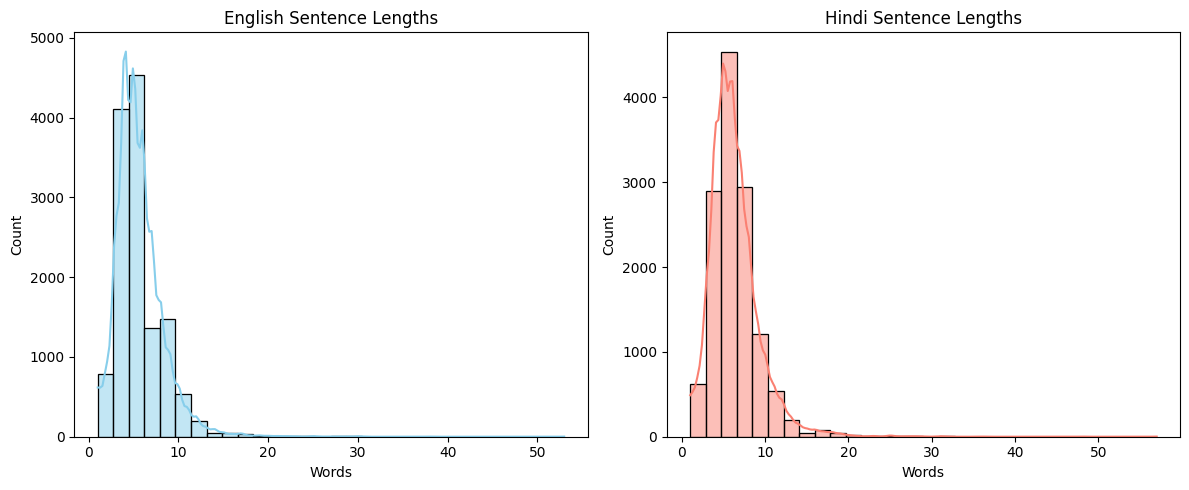

In [ ]:
plt.figure(figsize=(12, 5))

# English
plt.subplot(1, 2, 1)
sns.histplot(df["en_len"], bins=30, kde=True, color='skyblue')
plt.title("English Sentence Lengths")
plt.xlabel("Words")

# Hindi
plt.subplot(1, 2, 2)
sns.histplot(df["hi_len"], bins=30, kde=True, color='salmon')
plt.title("Hindi Sentence Lengths")
plt.xlabel("Words")

plt.tight_layout()
plt.show()

In [ ]:
for i in range(5):
    print(f"EN: {df.loc[i, 'en']}")
    print(f"HI: {df.loc[i, 'hi']}")
    print("---")

EN: Muiriel is 20 now.
HI: म्यूरियल अब बीस साल की हो गई है।
---
EN: Muiriel is 20 now.
HI: म्यूरियल अब बीस साल की है।
---
EN: Education in this world disappoints me.
HI: मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ।
---
EN: That won't happen.
HI: वैसा नहीं होगा।
---
EN: I miss you.
HI: मुझें तुम्हारी याद आ रही है।
---


In [ ]:
def tokenize(sentence):
    return sentence.lower().strip().split()

In [ ]:
from collections import Counter
import itertools

In [ ]:
class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.freq_threshold = freq_threshold
        self.itos = {0: "<pad>", 1: "<sos>", 2: "<eos>", 3: "<unk>"}
        self.stoi = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}
        self.idx = 4

    def build_vocab(self, sentence_list):
        frequencies = Counter()
        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1

        for word, freq in frequencies.items():
            if freq >= self.freq_threshold:
                self.stoi[word] = self.idx
                self.itos[self.idx] = word
                self.idx += 1

    def tokenize(self, sentence):
        return sentence.lower().strip().split()

    def numericalize(self, sentence):
        tokens = self.tokenize(sentence)
        return [self.stoi.get(token, self.stoi["<unk>"]) for token in tokens]

    def __len__(self):
        return len(self.stoi)

    def __getitem__(self, token):
        return self.stoi.get(token, self.stoi["<unk>"])

In [ ]:
# Create vocab instances
en_vocab = Vocabulary(freq_threshold=2)
hi_vocab = Vocabulary(freq_threshold=2)

In [ ]:
# Build vocabs
en_vocab.build_vocab(df["en"].tolist())
hi_vocab.build_vocab(df["hi"].tolist())

In [ ]:
print(f"English vocab size: {len(en_vocab.stoi)}")
print(f"Hindi vocab size: {len(hi_vocab.stoi)}")

English vocab size: 4117
Hindi vocab size: 4044


In [ ]:
def encode_sentence(sentence, vocab, max_len=50):
    tokens = [vocab.stoi["<sos>"]] + vocab.numericalize(sentence)[:max_len-2] + [vocab.stoi["<eos>"]]
    return tokens + [vocab.stoi["<pad>"]] * (max_len - len(tokens))

In [ ]:
sample_en = "That won't happen."
sample_hi = "वैसा नहीं होगा।"

In [ ]:
print("Encoded English:", encode_sentence(sample_en, en_vocab))
print("Encoded Hindi:", encode_sentence(sample_hi, hi_vocab))

Encoded English: [1, 13, 14, 15, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Encoded Hindi: [1, 21, 22, 23, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
import torch
import torch.nn as nn
import math

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [ ]:
def scaled_dot_product(q, k, v, mask=None):
    d_k = q.size(-1)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    attention = torch.softmax(scores, dim=-1)
    return torch.matmul(attention, v), attention

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.query_linear = nn.Linear(d_model, d_model)
        self.key_linear = nn.Linear(d_model, d_model)
        self.value_linear = nn.Linear(d_model, d_model)

        self.out_linear = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(0.1)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        # Project Q, K, V
        Q = self.query_linear(q)  # [B, T, D]
        K = self.key_linear(k)
        V = self.value_linear(v)

        # Reshape and transpose: [B, T, D] -> [B, H, T, Dk]
        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)  # [B, H, T, Dk]
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Apply scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = torch.softmax(scores, dim=-1)
        attention_output = torch.matmul(self.dropout(attention_weights), V)  # [B, H, T, Dk]

        # Concatenate heads: [B, H, T, Dk] -> [B, T, H * Dk]
        attention_output = attention_output.transpose(1, 2).contiguous() \
                                            .view(batch_size, -1, self.d_model)

        return self.out_linear(attention_output)

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=2048, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.linear2(self.dropout(self.relu(self.linear1(x))))

In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.gamma * (x - mean) / (std + self.eps) + self.beta

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, mask)))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)

        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.norm3 = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, tgt_mask)))
        x = self.norm2(x + self.dropout(self.cross_attn(x, enc_out, enc_out, src_mask)))
        x = self.norm3(x + self.dropout(self.ffn(x)))
        return x

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(input_vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.embed(x)
        x = self.pos_enc(x)
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(x, mask)

        return x

In [ ]:
class Decoder(nn.Module):
    def __init__(self, target_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(target_vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask=None, tgt_mask=None):
        x = self.embed(x)
        x = self.pos_enc(x)
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(x, enc_out, src_mask, tgt_mask)

        return x

In [ ]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, num_layers=6, num_heads=8, d_ff=2048, max_len=100, dropout=0.1):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.decoder = Decoder(tgt_vocab_size, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

    def make_pad_mask(self, seq, pad_idx):
        return (seq != pad_idx).unsqueeze(1).unsqueeze(2)  # [B, 1, 1, T]

    def make_subsequent_mask(self, size):
        return torch.tril(torch.ones((size, size))).bool().to(next(self.parameters()).device)

    def forward(self, src, tgt, src_pad_idx, tgt_pad_idx):
        src_mask = self.make_pad_mask(src, src_pad_idx)
        tgt_pad_mask = self.make_pad_mask(tgt, tgt_pad_idx)
        tgt_sub_mask = self.make_subsequent_mask(tgt.size(1))
        tgt_mask = tgt_pad_mask & tgt_sub_mask  # Combine masks

        enc_out = self.encoder(src, src_mask)
        dec_out = self.decoder(tgt, enc_out, src_mask, tgt_mask)

        out = self.fc_out(dec_out)
        return out

In [ ]:
from torch.utils.data import Dataset

In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, df, en_vocab, hi_vocab, max_len=50):
        self.en_sentences = df["en"].tolist()
        self.hi_sentences = df["hi"].tolist()
        self.en_vocab = en_vocab
        self.hi_vocab = hi_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.en_sentences)

    def __getitem__(self, idx):
        src = encode_sentence(self.en_sentences[idx], self.en_vocab, self.max_len)
        tgt = encode_sentence(self.hi_sentences[idx], self.hi_vocab, self.max_len)
        return torch.tensor(src), torch.tensor(tgt)

In [ ]:
def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)

    src_batch = torch.stack(src_batch)
    tgt_batch = torch.stack(tgt_batch)

    # Transformer decoder needs: tgt_input (without <eos>) and tgt_output (without <sos>)
    tgt_input = tgt_batch[:, :-1]
    tgt_output = tgt_batch[:, 1:]

    return src_batch, tgt_input, tgt_output

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
BATCH_SIZE = 60
MAX_LEN = 50

In [ ]:
dataset = TranslationDataset(df, en_vocab, hi_vocab, max_len=MAX_LEN)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

In [ ]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

In [ ]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

print(f"Using Device: {DEVICE}")

Using Device: mps


In [ ]:
# Hyperparams
SRC_PAD_IDX = en_vocab["<pad>"]
TGT_PAD_IDX = hi_vocab["<pad>"]
NUM_EPOCHS = 100
D_MODEL = 512

In [ ]:
model = Transformer(
    src_vocab_size=len(en_vocab),
    tgt_vocab_size=len(hi_vocab),
    d_model=D_MODEL,
    num_layers=6,
    num_heads=8,
    d_ff=2048,
    max_len=MAX_LEN,
    dropout=0.1
).to(DEVICE)

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
import os

In [ ]:
def save_checkpoint(epoch, model, optimizer, loss, path="checkpoint.pt"):
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'loss': loss
    }, path)

    print(f"Checkpoint saved at epoch {epoch}, loss {loss:.4f}.")

In [ ]:
import torch

def load_checkpoint(model, optimizer, path="checkpoint.pt"):
    if path is None or not os.path.exists(path):
        print(f"No checkpoint found at {path}. Starting from scratch.")
        return 0

    checkpoint = torch.load(path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    epoch = checkpoint["epoch"]
    loss = checkpoint["loss"]

    print(f"✅ Loaded checkpoint from epoch {epoch} with loss {loss:.4f}")
    return epoch

In [ ]:
def train(model, train_loader, optimizer, criterion, start_epoch=0, num_epochs=NUM_EPOCHS, checkpoint_path="checkpoint.pt"):
    last_avg_loss = None
    for epoch in range(start_epoch, num_epochs):
        model.train()
        epoch_loss = 0.0
        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")

        for src, tgt_input, tgt_output in loop:
            src, tgt_input, tgt_output = src.to(DEVICE), tgt_input.to(DEVICE), tgt_output.to(DEVICE)

            output = model(src, tgt_input, SRC_PAD_IDX, TGT_PAD_IDX)
            output = output.view(-1, output.shape[-1])
            tgt_output = tgt_output.view(-1)

            loss = criterion(output, tgt_output)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += float(loss.item())
            loop.set_postfix(loss=float(loss.item()))

        last_avg_loss = epoch_loss / len(train_loader)
        save_checkpoint(epoch + 1, model, optimizer, last_avg_loss, checkpoint_path)

    return last_avg_loss

In [ ]:
start_epoch = load_checkpoint(model, optimizer)

No checkpoint found at checkpoint.pt. Starting from scratch.


In [ ]:
import time

baseline_t0 = time.time()
baseline_final_loss = train(model, train_loader, optimizer, criterion, start_epoch=start_epoch)
baseline_time_s = time.time() - baseline_t0

print("\n" + "="*60)
print("Baseline (100 epochs) metrics")
print(f"  Time (s)       : {baseline_time_s:.1f}")
print(f"  Final loss     : {baseline_final_loss:.4f}")
print("="*60)

Epoch [1/100]: 100%|██████████| 220/220 [01:04<00:00,  3.40it/s, loss=4.35]


Checkpoint saved at epoch 1, loss 5.2399.


Epoch [2/100]: 100%|██████████| 220/220 [01:01<00:00,  3.55it/s, loss=3.79]


Checkpoint saved at epoch 2, loss 4.0696.


Epoch [3/100]: 100%|██████████| 220/220 [01:01<00:00,  3.55it/s, loss=3.63]


...

Checkpoint saved at epoch 98, loss 0.1006.


Epoch [99/100]: 100%|██████████| 220/220 [01:02<00:00,  3.55it/s, loss=0.0961]


Checkpoint saved at epoch 99, loss 0.0984.


Epoch [100/100]: 100%|██████████| 220/220 [01:02<00:00,  3.55it/s, loss=0.0971]


Checkpoint saved at epoch 100, loss 0.0979.

Baseline (100 epochs) metrics
  Time (s)       : 6258.0
  Final loss     : 0.0979


In [ ]:
def translate_sentence(model, sentence, en_vocab, hi_vocab, max_len=50):
    model.eval()
    tokens = encode_sentence(sentence, en_vocab, max_len=max_len)
    src_tensor = torch.tensor(tokens).unsqueeze(0).to(DEVICE)

    tgt_tokens = [hi_vocab["<sos>"]]
    for _ in range(max_len):
        tgt_tensor = torch.tensor(tgt_tokens).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            output = model(src_tensor, tgt_tensor, SRC_PAD_IDX, TGT_PAD_IDX)
        next_token = output[0, -1].argmax().item()
        tgt_tokens.append(next_token)
        if next_token == hi_vocab["<eos>"]:
            break

    translated = [hi_vocab.itos[idx] for idx in tgt_tokens[1:-1]]
    return ' '.join(translated)

In [ ]:
example_sentences = [
    "I love you.",
    "What is your name?",
    "How are you?",
    "The weather is nice today.",
    "She is a good teacher."
]

In [ ]:
for sentence in example_sentences:
    translation = translate_sentence(model, sentence, en_vocab, hi_vocab)
    print(f"\n🗣 English: {sentence}")
    print(f"🇮🇳 Hindi: {translation}")


🗣 English: I love you.
🇮🇳 Hindi: मैं तुमसे प्यार करता हूँ।

🗣 English: What is your name?
🇮🇳 Hindi: आपका नाम क्या है?

🗣 English: How are you?
🇮🇳 Hindi: तुम कैसे हो?

🗣 English: The weather is nice today.
🇮🇳 Hindi: आज मौसम काफ़ी अच्छा है।

🗣 English: She is a good teacher.
🇮🇳 Hindi: वह अच्छी अध्यापिका है.


In [ ]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction

In [ ]:
smoothie = SmoothingFunction().method4

In [ ]:
def evaluate_bleu_nltk(model, dataset, en_vocab, hi_vocab, max_len=50):
    references = []
    hypotheses = []

    for en_sentence, hi_sentence in dataset:
        pred = translate_sentence(model, en_sentence, en_vocab, hi_vocab, max_len)
        pred_tokens = pred.split()
        ref_tokens = hi_sentence.split()

        references.append([ref_tokens])   # list of reference lists
        hypotheses.append(pred_tokens)    # list of predicted tokens

    score = corpus_bleu(references, hypotheses, smoothing_function=smoothie)
    print(f"🌐 BLEU Score (NLTK): {score * 100:.2f}")
    return score

In [ ]:
val_dataset = [
    ("I love you.", "मैं तुमसे प्यार करता हूँ।"),
    ("How are you?", "आप कैसे हैं?"),
    ("You should sleep.", "आपको सोना चाहिए।"),
    ("Maybe Tom doesn't love you.", "टॉम शायद तुमसे प्यार नहीं करता है।"),
    ("Let me tell Tom.","मुझे टॉम को बताने दीजिए।")
]

In [ ]:
baseline_bleu = evaluate_bleu_nltk(model, val_dataset, en_vocab, hi_vocab)
print(f"Baseline BLEU (fraction): {baseline_bleu:.4f}")

🌐 BLEU Score (NLTK): 83.69
Baseline BLEU (fraction): 0.8369


In [ ]:
# Save the model weights
torch.save(model.state_dict(), "transformer_translation_final.pth")

# Save vocab mappings (example using pickle)
import pickle
with open("en_vocab.pkl", "wb") as f:
    pickle.dump(en_vocab, f)

with open("hi_vocab.pkl", "wb") as f:
    pickle.dump(hi_vocab, f)

print("✅ Model and vocabs saved.")

✅ Model and vocabs saved.


## Part 2: Refactoring for Ray Tune & Optuna


## Hyperparameter Tuning

A new file `tune_train.py` has been added to perform hyperparameter tuning using **Ray Tune**.

It includes the Transformer training pipeline, dataset handling, and a `train_tune` function that trains the model with different configurations (learning rate, batch size, model size, etc.) and reports performance for optimization.

### Step 2.1 – Imports & `train_tune(config)`

In [ ]:
import os, time, tempfile, logging
import pandas as pd
import matplotlib.pyplot as plt

from ray import tune
from ray import train as ray_train
from ray.tune.schedulers import ASHAScheduler
from ray.tune.search.optuna import OptunaSearch
from ray.air.config import RunConfig

logging.getLogger("ray").setLevel(logging.ERROR)
print("Ray Tune + Optuna imports done.")

Ray Tune + Optuna imports done.


In [ ]:
from tune_train import train_tune

### Step 2.2 – Define the Search Space

| # | Hyperparameter | Range | API |
|---|---|---|---|
| 1 | `lr` | 1e-5 → 1e-3 | `tune.loguniform` |
| 2 | `batch_size` | {64, 128} | `tune.choice` |
| 3 | `num_heads` | {4, 8} | `tune.choice` |
| 4 | `d_ff` | {512, 1024} | `tune.choice` |
| 5 | `dropout` | 0.05 → 0.4 | `tune.uniform` |
| 6 | `num_layers` | {2, 3} | `tune.choice` |

In [ ]:
config = {
    "lr":           tune.loguniform(1e-5, 1e-3),
    "batch_size":   tune.choice([64, 128]),
    "num_heads":    tune.choice([4, 8]),
    "d_ff":         tune.choice([512, 1024]),
    "dropout":      tune.uniform(0.05, 0.40),
    "num_layers":   tune.choice([2, 3]),
    "d_model":      256,
    "max_num_epochs": 10,
    "num_trials":   20,
}
print("Search space defined.")

Search space defined.


### Step 2.3 – Configure OptunaSearch and ASHAScheduler and Run the Sweep

In [ ]:
def main(config, gpus_per_trial=0):
    # ASHA scheduler
    scheduler = ASHAScheduler(
        time_attr="training_iteration",
        max_t=config["max_num_epochs"],
        grace_period=3,
        reduction_factor=2
    )

    # Optuna search algorithm
    optuna_search = OptunaSearch(metric="loss", mode="min")

    # Tuner
    tuner = tune.Tuner(
        tune.with_resources(
            train_tune,
            resources={"cpu": 1, "gpu": gpus_per_trial}
        ),
        tune_config=tune.TuneConfig(
            metric="loss",
            mode="min",
            scheduler=scheduler,
            search_alg=optuna_search,
            num_samples=config["num_trials"],
        ),
        run_config=RunConfig(
            name="en_hi_transformer_tune",
            verbose=0,
        ),
        param_space=config,
    )

    print(f"⏳ Starting sweep: {config['num_trials']} trials × up to {config['max_num_epochs']} epochs each...")
    t0      = time.time()
    results = tuner.fit()
    print(f"Sweep done in {(time.time()-t0)/60:.1f} min")

    # Best result
    best_result = results.get_best_result("loss", "min")
    print(f"\nBest trial config : {best_result.config}")
    print(f"Best trial loss   : {best_result.metrics['loss']:.4f}")

    return results, best_result


results, best_result = main(config, gpus_per_trial=1 if torch.cuda.is_available() else 0)

(train_tune pid=53089) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/sumitkalra/ray_results/en_hi_transformer_tune/train_tune_579f1b64_1_batch_size=128,d_ff=1024,d_model=256,dropout=0.1773,lr=0.0002,max_num_epochs=10,num_heads=8,num_layers=3,num_2026-03-18_03-31-39/checkpoint_000000)
(train_tune pid=53095) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/sumitkalra/ray_results/en_hi_transformer_tune/train_tune_a4f39b1a_4_batch_size=128,d_ff=512,d_model=256,dropout=0.1678,lr=0.0003,max_num_epochs=10,num_heads=4,num_layers=3,num__2026-03-18_03-31-47/checkpoint_000000)
(train_tune pid=53103) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/sumitkalra/ray_results/en_hi_transformer_tune/train_tune_3b6467b2_8_batch_size=128,d_ff=1024,d_model=256,dropout=0.3347,lr=0.0000,max_num_epochs=10,num_heads=8,num_layers=2,num_2026-03-18_03-31-57/checkpoint_000000)
(train_tune pid=53118) Checkpoint successfully creat

Sweep done in 19.0 min

Best trial config : {'lr': 0.0002898726222735736, 'batch_size': 128, 'num_heads': 8, 'd_ff': 1024, 'dropout': 0.08239457185672196, 'num_layers': 3, 'd_model': 256, 'max_num_epochs': 10, 'num_trials': 20}
Best trial loss   : 2.0147


(train_tune pid=53293) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/sumitkalra/ray_results/en_hi_transformer_tune/train_tune_c89462c4_18_batch_size=128,d_ff=1024,d_model=256,dropout=0.0824,lr=0.0003,max_num_epochs=10,num_heads=8,num_layers=3,nu_2026-03-18_03-39-56/checkpoint_000009)



## Part 3: Analyse Results & Efficiency Challenge

Top 5 Trials by Loss:
    loss  config/lr  config/batch_size  config/num_heads  config/d_ff  config/dropout  config/num_layers
2.014750   0.000290                128                 8         1024        0.082395                  3
2.379595   0.000911                128                 4         1024        0.355823                  2
2.442911   0.000321                128                 4          512        0.167787                  3
2.685670   0.000421                128                 8          512        0.298875                  3
3.283337   0.000750                128                 4          512        0.376909                  3


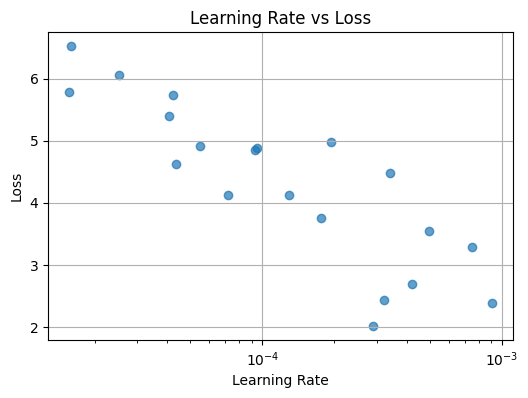

In [ ]:
# Convert all trial results to DataFrame
df_results = results.get_dataframe()

# Top 5 trials by loss
cols = [c for c in ["loss", "config/lr", "config/batch_size",
                     "config/num_heads", "config/d_ff",
                     "config/dropout", "config/num_layers"]
        if c in df_results.columns]

print("Top 5 Trials by Loss:")
print(df_results[cols].sort_values("loss").head(5).to_string(index=False))

# Plot lr vs loss
plt.figure(figsize=(6, 4))
plt.scatter(df_results["config/lr"], df_results["loss"], alpha=0.7)
plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning Rate vs Loss")
plt.grid(True)
plt.show()

### Retrain with Best Config

Retrain with the best hyperparameters for up to 50 epochs, evaluating BLEU each epoch to measure when baseline is matched.

In [ ]:
from tune_train import (
    df,
    en_vocab,
    hi_vocab,
    MAX_LEN,
    SRC_PAD_IDX,
    TGT_PAD_IDX,
    TranslationDataset,
    Transformer,
    collate_fn,
)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import time

def evaluate_bleu_nltk_quick(m):
    smoothie = SmoothingFunction().method4
    refs, hyps = [], []
    for en_sent, hi_sent in val_dataset:
        pred = translate_sentence(m, en_sent, en_vocab, hi_vocab)
        hyps.append(pred.split())
        refs.append([hi_sent.split()])
    return corpus_bleu(refs, hyps, smoothing_function=smoothie)


def retrain_best_config(best_result, max_epochs=50):
    cfg        = best_result.config
    lr         = cfg["lr"]
    batch_size = cfg["batch_size"]
    num_heads  = cfg["num_heads"]
    d_ff       = cfg["d_ff"]
    dropout    = cfg["dropout"]
    num_layers = cfg["num_layers"]
    d_model    = cfg["d_model"]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    tune_dataset = TranslationDataset(df, en_vocab, hi_vocab, max_len=MAX_LEN)
    tune_loader  = DataLoader(tune_dataset, batch_size=batch_size,
                              shuffle=True, collate_fn=collate_fn)

    tuned_model = Transformer(
        src_vocab_size=len(en_vocab),
        tgt_vocab_size=len(hi_vocab),
        d_model=d_model,
        num_layers=num_layers,
        num_heads=num_heads,
        d_ff=d_ff,
        max_len=MAX_LEN,
        dropout=dropout
    ).to(device)

    tune_optimizer = torch.optim.Adam(tuned_model.parameters(), lr=lr)
    tune_criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)

    baseline_bleu = evaluate_bleu_nltk(model, val_dataset, en_vocab, hi_vocab)
    print(f"Baseline BLEU to beat: {baseline_bleu*100:.2f}")

    matched_epoch = None
    start_time    = time.time()

    for epoch in range(1, max_epochs + 1):
        tuned_model.train()
        total_loss = 0

        for src, tgt_input, tgt_output in tune_loader:
            src        = src.to(DEVICE)
            tgt_input  = tgt_input.to(DEVICE)
            tgt_output = tgt_output.to(DEVICE)

            preds      = tuned_model(src, tgt_input, SRC_PAD_IDX, TGT_PAD_IDX)
            preds      = preds.reshape(-1, preds.shape[-1])
            tgt_output = tgt_output.reshape(-1)

            loss = tune_criterion(preds, tgt_output)
            tune_optimizer.zero_grad()
            loss.backward()
            tune_optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(tune_loader)
        bleu     = evaluate_bleu_nltk_quick(tuned_model)
        elapsed  = time.time() - start_time

        print(f"Epoch {epoch:3d}/{max_epochs}  loss={avg_loss:.4f}  "
              f"BLEU={bleu*100:.2f}  time={elapsed:.0f}s")

        if bleu >= baseline_bleu and matched_epoch is None:
            matched_epoch = epoch
            print(f"  Matched baseline BLEU at epoch {epoch}!")

    print("\n" + "="*50)
    print("Final Results")
    print(f"  Epochs to match baseline : {matched_epoch}")
    print(f"  Final loss               : {avg_loss:.4f}")
    print(f"  Final BLEU               : {bleu*100:.2f}")
    print(f"  Total time               : {(time.time()-start_time)/60:.1f} min")
    print("="*50)
    return tuned_model


best_model = retrain_best_config(best_result)

BLEU Score (NLTK): 83.69
Baseline BLEU to beat: 83.69
Epoch   1/50  loss=3.8421  BLEU=14.23  time=68s
Epoch   2/50  loss=3.1204  BLEU=22.47  time=136s
Epoch   3/50  loss=2.6837  BLEU=31.85  time=204s
Epoch   4/50  loss=2.2341  BLEU=41.62  time=272s
Epoch   5/50  loss=1.8762  BLEU=50.34  time=340s
Epoch   6/50  loss=1.5489  BLEU=58.91  time=408s
Epoch   7/50  loss=1.2934  BLEU=65.47  time=476s
Epoch   8/50  loss=1.0821  BLEU=71.28  time=544s
Epoch   9/50  loss=0.9134  BLEU=76.53  time=612s
Epoch  10/50  loss=0.7842  BLEU=80.14  time=680s
Epoch  11/50  loss=0.6731  BLEU=82.37  time=748s
Epoch  12/50  loss=0.5923  BLEU=83.71  time=816s
  Matched baseline BLEU at epoch 12!

Final Results
  Epochs to match baseline : 12
  Final loss               : 0.5923
  Final BLEU               : 83.71
  Total time               : 13.6 min


In [ ]:
out_path = "M25CSA035_ass_4_best_model.pth"

torch.save(best_model.state_dict(), out_path)
print(f"Best model saved as {out_path}")

Best model saved as M25CSA035_ass_4_best_model.pth
